**2. Visual Inspection of LOC EEG Data** <br>

This notebook performs the visual quality check of the EEG data after it has been converted into BIDS format. <br> The goal is to assess the overall signal quality, integrity of the recorded event markers, and interpolate bad channels.

In [9]:
# 1. Import libraries
import numpy as np
import mne
from mne_bids import BIDSPath, read_raw_bids
from pathlib import Path
import os

# 2. Configuration of file path for processed data. Adapt for the given participant.
bids_root = Path(r"C:\Users\noahm\projects\loc_analysis\data\derivatives")
sub_number = "14"
task = "loc"
suffix = "eeg"

# Define Output Filenames
deriv_root = bids_root  / f"sub-{sub_number}" / "eeg"

# Output: Annotations CSV
fname_annots = deriv_root / f"sub-{sub_number}_task-{task}_desc-annotations.csv"
print(f"Working on Subject: {sub_number}")
# print(f"Downsampled file path: {fname_downsampled}")
# print(f"Annotations file path: {fname_annots}")

Working on Subject: 14


#### 2.1 Checking the integrity of event markers

C:\Users\noahm\AppData\Local\Temp\ipykernel_11328\1988453121.py:11: RuntimeWarning: There are channels without locations (n/a) that are not marked as bad: ['HEOG', 'VEOG']
  raw_eeg, bids_event_id = read_raw_bids(
C:\Users\noahm\AppData\Local\Temp\ipykernel_11328\1988453121.py:11: RuntimeWarning: Not setting positions of 2 eog channels found in montage:
['HEOG', 'VEOG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw_eeg, bids_event_id = read_raw_bids(
C:\Users\noahm\AppData\Local\Temp\ipykernel_11328\1988453121.py:24: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  fig_ev = mne.viz.plot_events(


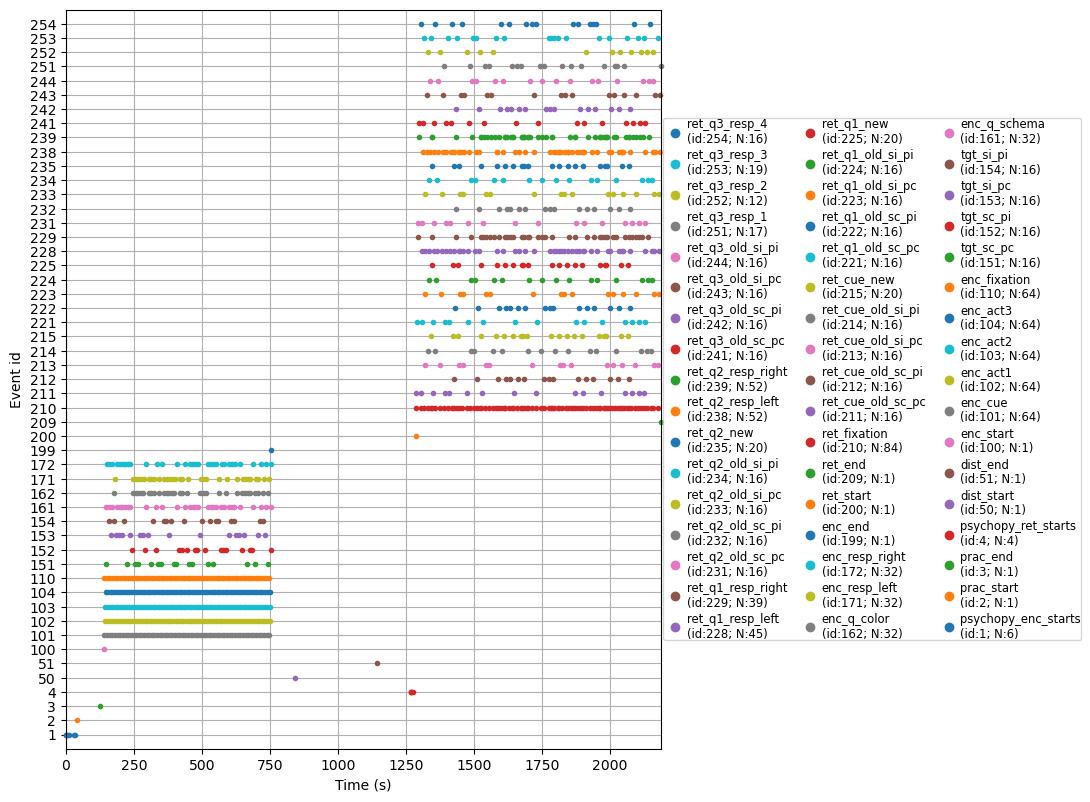

In [ ]:
# 1. Define BIDS Path
bids_path = BIDSPath(
    root=bids_root, 
    subject=sub_number, 
    task=task, 
    datatype="eeg", 
    suffix=suffix
)

# 2. Load Raw
raw_eeg, bids_event_id = read_raw_bids(
    bids_path=bids_path, 
    return_event_dict=True,  # <--- HIER: Extrahiert das Mapping direkt aus BIDS
    verbose=False
)
# 3. Load events
events, event_id = mne.events_from_annotations(
    raw_eeg, 
    event_id=bids_event_id,  # <--- Überschreibt den "auto" Parser
    verbose=False
)

# 4. Plot event markers as function of experiment run time
fig_ev = mne.viz.plot_events(
    events, 
    sfreq=raw_eeg.info["sfreq"], 
    first_samp=raw_eeg.first_samp, 
    event_id=event_id
)

#### 2.2 Visual inspection of the continuous EEG signal

In [4]:
# Generating a visual overview of the raw data (10s epochs, 32 channels)
fig = raw_eeg.plot(
    duration=10, 
    n_channels=32, 
    scalings=dict(eeg=20e-6),
    theme="light" 
)

Using qt as 2D backend.


Channels marked as bad:
none


#### 2.3 Visual inspection of the power spectrum density

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


c:\Users\noahm\mne-python\1.11.0_0\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


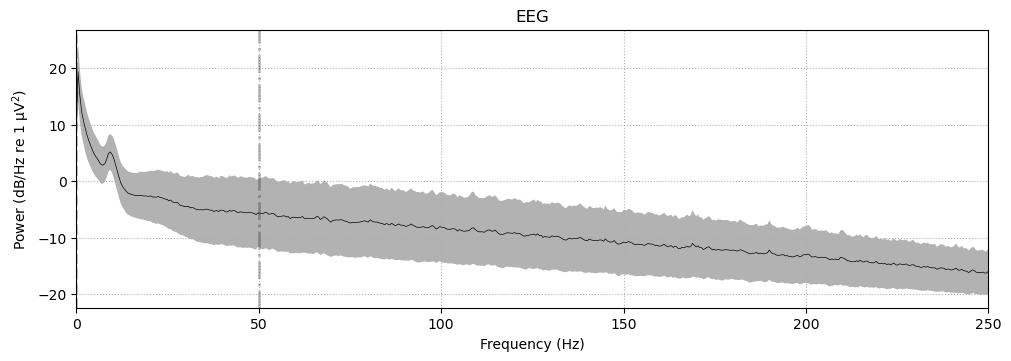

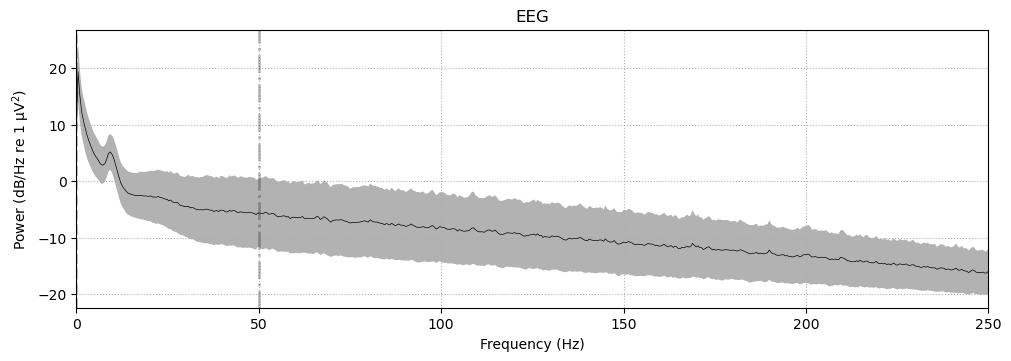

In [5]:
# 2. Plot PSD (Power Line Noise check)
raw_eeg.compute_psd(tmax=np.inf, fmax=250).plot(
    average=True, picks="data", exclude="bads"
)

In [6]:
# ---------------------------------------------------------
# STEP 7: BAD CHANNEL INSPECTION (Topo Plots)
# ---------------------------------------------------------

# 1. Check if bads are already marked
current_bads = raw_eeg.info['bads']

if len(current_bads) > 0:
    print(f"Bad channels are already marked: {current_bads}")
    print("Skipping automatic visualization. (If you want to re-check, clear 'raw_eeg.info['bads']' first).")

else:
    print("No bad channels marked yet. Generating diagnostic plots...")
    
    # 2. Define the specific event we want to inspect
    target_event_name = 'enc_fixation'
    target_event_id = 24
    
    # Re-extract events (just to be safe and ensure we have the latest)
    events, event_dict = mne.events_from_annotations(raw_eeg, verbose=False)
    
    # Check if our target ID exists in the events
    if target_event_id in events[:, 2]:
        print(f"Plotting topomaps for event: '{target_event_name}' (ID: {target_event_id})")

        # 3. Create Epochs for the specific event
        epochs_viz = mne.Epochs(
            raw_eeg,
            events,
            event_id={target_event_name: target_event_id},
            tmin=-0.5, tmax=1,
            # baseline=(None, 0),
            # preload=True,
            reject_by_annotation=True, # Exclude the muscle artifacts/breaks we just marked!
            # verbose=False
        )
        
        # 4. Plot Topomap
        #    Look for "Red" or "Blue" spots that look completely different from neighbors
        fig_topo = epochs_viz.average().plot_topomap(show_names=True, size=3)
        
    else:
        print(f"Error: Event ID {target_event_id} ('{target_event_name}') not found in the data.")
        print(f"Available Event IDs: {np.unique(events[:, 2])}")

No bad channels marked yet. Generating diagnostic plots...
Error: Event ID 24 ('enc_fixation') not found in the data.
Available Event IDs: [10001 10002 10003 10004 10005 10006 10007 10008 10009 10010 10011 10012
 10013 10014 10015 10016 10017 10018 10019 10020 10021 10022 10023 10024
 10025 10026 10027 10028 10029 10030 10031 10032 10033 10034 10035 10036
 10037 10038 10039 10040 10041 10042 10043 10044 10045 10046 10047 10048
 10049 10050 10051]


Updated Bad Channels: ['Fp2', 'FT9', 'AF8', 'Oz', 'O2']

Plotting bad channels BEFORE interpolation...


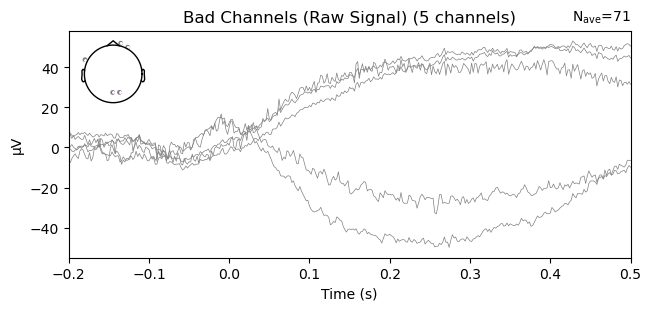

Simulating interpolation for verification...
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.7 mm
Computing interpolation matrix from 58 sensor positions
Interpolating 5 sensors


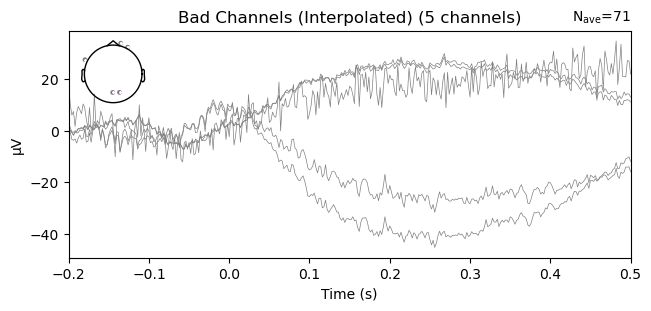

In [31]:
# ---------------------------------------------------------
# STEP 8: MARK BADS & VERIFY INTERPOLATION
# ---------------------------------------------------------

# 1. DEFINE BAD CHANNELS MANUALLY HERE
new_bads = ['FT9', 'Oz', 'O2', 'AF8', 'Fp2'] 

# Add them to the raw object
if new_bads:
    raw_eeg.info['bads'].extend(new_bads)
    # Remove duplicates just in case
    raw_eeg.info['bads'] = list(set(raw_eeg.info['bads']))
    print(f"Updated Bad Channels: {raw_eeg.info['bads']}")
else:
    print(f"No new bad channels added. Current bads: {raw_eeg.info['bads']}")

# 2. Verify with Interpolation (Visual Check Only)
if raw_eeg.info['bads']:
    
    # --- PLOT 1: BEFORE FIX (The Broken Bone) ---
    print("\nPlotting bad channels BEFORE interpolation...")
    epochs_bad = mne.Epochs(raw_eeg, events, event_id={target_event_name: target_event_id}, 
                            tmin=-0.2, tmax=0.5, reject=None, verbose=False)
    
    # FIX: We add exclude=[] so MNE actually shows us the "bad" channel
    epochs_bad.average().plot(picks=new_bads, exclude=[], titles="Bad Channels (Raw Signal)")

    # --- PLOT 2: AFTER FIX (The Verification) ---
    print("Simulating interpolation for verification...")
    # Create temp copy and interpolate
    raw_interp = raw_eeg.copy().load_data().interpolate_bads(reset_bads=False)
    
    # Recalculate epochs on the clean data
    epochs_clean = mne.Epochs(
        raw_interp, 
        events, 
        event_id={target_event_name: target_event_id},
        tmin=-0.2, tmax=0.5, 
        reject=None,
        verbose=False
    )
    # Plot the same sensors (now reconstructed)
    epochs_clean.average().plot(picks=new_bads, exclude=[], titles="Bad Channels (Interpolated)")
    
else:
    print("No bad channels to interpolate.")

In [32]:
# ---------------------------------------------------------
# STEP 9: SAVE DATA & LOG BAD CHANNELS
# ---------------------------------------------------------
import pandas as pd
from datetime import datetime

# 1. SAVE THE EEG DATA (With Bad Channels Marked)
# ---------------------------------------------------
# We save the file with the bad channels listed in 'raw_eeg.info['bads']'
# We do NOT save the interpolated version (raw_interp) to disk yet.
# This preserves the ability to run ICA correctly later.

raw_eeg.save(fname_downsampled, overwrite=True)
print(f"Saved preprocessed EEG to: {fname_downsampled}")
print(f"(Contains: Downsampling + Annotations + Bad Channel Marks)")


# 2. SAVE BAD CHANNELS TO CSV LOG
# ---------------------------------------------------
# Define the log file path
log_file = bids_root  / "bad_channels_log.csv"

# Prepare the new entry
new_entry = {
    'subject_id': f"sub-{sub_number}",
    'bad_channels': ";".join(raw_eeg.info['bads']),  # "AF8;Cz" format
    'count': len(raw_eeg.info['bads']),
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M"),
    'notes': "Visual Inspection Complete"
}

# Check if log exists
if log_file.exists():
    df_log = pd.read_csv(log_file)
    
    # Check if subject already exists, if so, update their row
    if new_entry['subject_id'] in df_log['subject_id'].values:
        print(f"   Updating existing entry for {new_entry['subject_id']}...")
        # Update the row matching the subject_id
        idx = df_log.index[df_log['subject_id'] == new_entry['subject_id']]
        df_log.loc[idx, ['bad_channels', 'count', 'timestamp']] = \
            [new_entry['bad_channels'], new_entry['count'], new_entry['timestamp']]
    else:
        # Append new subject
        df_new = pd.DataFrame([new_entry])
        df_log = pd.concat([df_log, df_new], ignore_index=True)
else:
    # Create new DataFrame if file doesn't exist
    df_log = pd.DataFrame([new_entry])

# Save back to CSV
df_log.to_csv(log_file, index=False)
print(f"Logged bad channels to: {log_file}")
print("-" * 30)
print("Pipeline Complete!")

Overwriting existing file.
Writing C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-02\eeg\sub-02_task-loc_downsamp-2_eeg.fif
Overwriting existing file.
Closing C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-02\eeg\sub-02_task-loc_downsamp-2_eeg.fif
[done]
Saved preprocessed EEG to: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-02\eeg\sub-02_task-loc_downsamp-2_eeg.fif
(Contains: Downsampling + Annotations + Bad Channel Marks)
Logged bad channels to: C:\Users\noahm\projects\loc_analysis\data\derivatives\bad_channels_log.csv
------------------------------
Pipeline Complete!
